In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
## (1)from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WBC_AP.csv to WBC_AP.csv


In [ ]:
import pandas as pd
df=pd.read_csv("WBC_AP.csv")
df.head()

/tmp/ipykernel_6992/3123928548.py:2: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("WBC_AP.csv")


,rural_or_urban,State Name,District Name,Block/Tehsil Name,Village Name,town_municipalty_name,ward_name,si_no_of_water_body_within_village_town,unique_id,water_body_name,...,no_people_benefited_by_water_body,ref_selection_id_wua_exists_name,extent_of_area_covered_by_wua,number_of_wua_formed,ref_selection_id_dip_sip_exists_name,ref_selection_id_water_body_encroached_name,ref_selection_id_encroachment_assessed_name,area_encroached_percentage,reason_water_body_in_use_name2,reason_water_body_in_use_name3
0,Rural,ANDHRA PRADESH,ANANTHAPUR,VENKATAGIRI,Rayadurg,NaN,NaN,1,1/28/550/005187/R00704/001,Cheruvu,...,298.0,No,NaN,NaN,Yes,No,NaN,NaN,NaN,NaN
1,Rural,ANDHRA PRADESH,WEST GODAVARI,AKIVIDU,Pedakapavaram,NaN,NaN,1,1/28/546/004975/588589/001,Panchaiti cheruvu,...,3500.0,No,NaN,NaN,Yes,No,NaN,NaN,NaN,NaN
2,Rural,ANDHRA PRADESH,WEST GODAVARI,AKIVIDU,Taratava,NaN,NaN,68,1/28/546/004975/588592/068,Mallareddy Srinivasarao7,...,3.0,NaN,NaN,NaN,No,No,NaN,NaN,NaN,NaN
3,Rural,ANDHRA PRADESH,KURNOOL,Kolimigundla,Chintalayapalle,NaN,NaN,6,1/28/552/005301/594589/006,sirlarchuruvu,...,4.0,No,NaN,NaN,Yes,No,NaN,NaN,NaN,NaN
4,Rural,ANDHRA PRADESH,WEST GODAVARI,BHIMADOLE,Agadallanka,NaN,NaN,61,1/28/546/004963/588362/061,Fishtank,...,1.0,NaN,NaN,NaN,No,No,NaN,NaN,NaN,NaN


In [ ]:
df.columns

Index(['rural_or_urban', 'State Name', 'District Name', 'Block/Tehsil Name',
       'Village Name', 'town_municipalty_name', 'ward_name',
       'si_no_of_water_body_within_village_town', 'unique_id',
       'water_body_name', 'basin_name', 'sub_basin_name',
       'ref_water_body_type_id_name', 'nature_of_storage', 'khasra_number',
       'water_body_loc_name', 'water_body_ownership_name',
       'ref_water_body_in_use_id_name',
       'ref_reason_water_body_in_use_id1_name', 'cca_water_body',
       'ipc_water_body', 'scheme_status_reason_name', 'water_body_nature_name',
       'manmade_water_body_type_name', 'construcion_year', 'construction_cost',
       'renovation_year', 'renovation_cost',
       'ref_water_body_under_repair_renovation_restoration_id_name',
       'scheme_under_revival_is_done', 'scheme_inclusion_year',
       'targeted_completion_year', 'estimated_cost',
       'target_potential_revival', 'irrigation_potential_revived',
       'water_spread_area_of_water_body', 

In [ ]:
columns_to_drop = [
'si_no_of_water_body_within_village_town',
'unique_id',
'water_body_name',
'khasra_number',
'water_body_loc_name',
'town_municipalty_name',
'ward_name',
'scheme_under_revival_is_done',
'scheme_inclusion_year',
'targeted_completion_year',
'estimated_cost',
'target_potential_revival',
'irrigation_potential_revived',
'extent_of_area_covered_by_wua',
'number_of_wua_formed',
'no_town_cities_benefited',
'ref_selection_id_encroachment_assessed_name',
'area_encroached_percentage',
'Village Name'
]

In [ ]:
df = df.drop(columns=columns_to_drop)

In [ ]:
cols_to_drop = [
    'nature_of_storage',
    'scheme_status_reason_name',
    'reason_water_body_in_use_name2',
    'reason_water_body_in_use_name3'
]

df = df.drop(columns=cols_to_drop)

In [ ]:
df['cca_water_body'] = df['cca_water_body'].fillna(0)

In [ ]:
df['ipc_water_body'] = df['ipc_water_body'].fillna(0)


In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

In [ ]:
df.isnull().sum()



,0
rural_or_urban,0
State Name,0
District Name,0
Block/Tehsil Name,0
basin_name,0
sub_basin_name,0
ref_water_body_type_id_name,0
water_body_ownership_name,0
ref_water_body_in_use_id_name,0
ref_reason_water_body_in_use_id1_name,0


In [ ]:
import numpy as np

# 1. Remove unstable rows (very small capacity)
df = df[df['storage_capacity_water_body_original'] > 100]

# 2. Create efficiency
df['efficiency_ratio'] = (
    df['storage_capacity_water_body_present'] /
    df['storage_capacity_water_body_original']
)

# 3. Create loss
df['loss_percentage'] = (
    (df['storage_capacity_water_body_original'] - df['storage_capacity_water_body_present']) /
    df['storage_capacity_water_body_original']
)

# 4. Fix people scale
df['people_benefited'] = np.log1p(df['no_people_benefited_by_water_body'])

In [ ]:
df[['efficiency_ratio','loss_percentage','people_benefited']].describe()

,efficiency_ratio,loss_percentage,people_benefited
count,1.685250e+05,168525.000000,168525.000000
mean,1.147450e+00,-0.147450,1.644845
std,2.616947e+01,26.169465,1.399678
min,2.000000e-07,-6665.666667,0.693147
25%,7.435897e-01,0.000000,0.693147
50%,7.435897e-01,0.256410,1.098612
75%,1.000000e+00,0.256410,1.945910
max,6.666667e+03,1.000000,13.592368


In [ ]:
df = df[
    df['storage_capacity_water_body_present'] <=
    df['storage_capacity_water_body_original']
]

In [ ]:
# Efficiency
df['efficiency_ratio'] = (
    df['storage_capacity_water_body_present'] /
    df['storage_capacity_water_body_original']
)

# Loss (correct now)
df['loss_percentage'] = (
    (df['storage_capacity_water_body_original'] - df['storage_capacity_water_body_present']) /
    df['storage_capacity_water_body_original']
)

In [ ]:
df[['efficiency_ratio','loss_percentage','people_benefited']].describe()

,efficiency_ratio,loss_percentage,people_benefited
count,1.644910e+05,164491.000000,164491.000000
mean,7.606734e-01,0.239327,1.641609
std,2.339656e-01,0.233966,1.396396
min,2.000000e-07,0.000000,0.693147
25%,7.435897e-01,0.017544,0.693147
50%,7.435897e-01,0.256410,1.098612
75%,9.824561e-01,0.256410,1.945910
max,1.000000e+00,1.000000,13.592368


In [ ]:
from sklearn.preprocessing import StandardScaler

features = ['efficiency_ratio', 'loss_percentage', 'people_benefited']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
df['cluster'].value_counts()

,count
cluster,
0,124239
2,25940
1,14312


In [ ]:
df.groupby('cluster')[features].mean()

,efficiency_ratio,loss_percentage,people_benefited
cluster,,,
0,0.815597,0.184403,1.059467
1,0.142826,0.857174,2.228762
2,0.838508,0.161492,4.105811


In [ ]:
cluster_names = {
    0: "Underutilized (Healthy, Low Impact)",
    1: "Critical (Highly Degraded)",
    2: "High-Value (Efficient & High Impact)"
}

df['cluster_label'] = df['cluster'].map(cluster_names)

In [ ]:
df['cluster_label'].value_counts()

,count
cluster_label,
"Underutilized (Healthy, Low Impact)",124239
High-Value (Efficient & High Impact),25940
Critical (Highly Degraded),14312


In [ ]:
sample_df = df.groupby('cluster', group_keys=False).apply(
    lambda x: x.sample(frac=0.03, random_state=42)
)

/tmp/ipykernel_6992/4072557056.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = df.groupby('cluster', group_keys=False).apply(


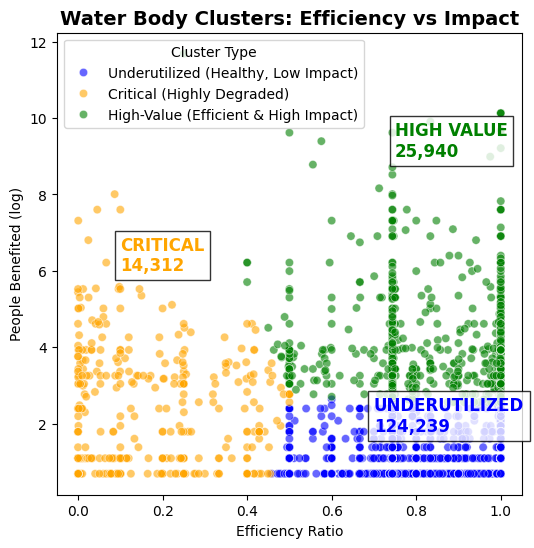

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# counts
counts = df['cluster_label'].value_counts()

plt.figure(figsize=(6,6))

sns.scatterplot(
    data=sample_df,
    x='efficiency_ratio',
    y='people_benefited',
    hue='cluster_label',
    palette={
        "Underutilized (Healthy, Low Impact)": "blue",
        "Critical (Highly Degraded)": "orange",
        "High-Value (Efficient & High Impact)": "green"
    },
    alpha=0.6
)

#  BIG BOLD LABELS WITH BOXES
plt.text(
    0.7, 1.8,
    f"UNDERUTILIZED\n{counts['Underutilized (Healthy, Low Impact)']:,}",
    fontsize=12, fontweight='bold', color='blue',
    bbox=dict(facecolor='white', alpha=0.8)
)

plt.text(
    0.1, 6,
    f"CRITICAL\n{counts['Critical (Highly Degraded)']:,}",
    fontsize=12, fontweight='bold', color='orange',
    bbox=dict(facecolor='white', alpha=0.8)
)

plt.text(
    0.75, 9,
    f"HIGH VALUE\n{counts['High-Value (Efficient & High Impact)']:,}",
    fontsize=12, fontweight='bold', color='green',
    bbox=dict(facecolor='white', alpha=0.8)
)

plt.title('Water Body Clusters: Efficiency vs Impact', fontsize=14, fontweight='bold')
plt.xlabel('Efficiency Ratio')
plt.ylabel('People Benefited (log)')

plt.legend(title='Cluster Type')
plt.show()

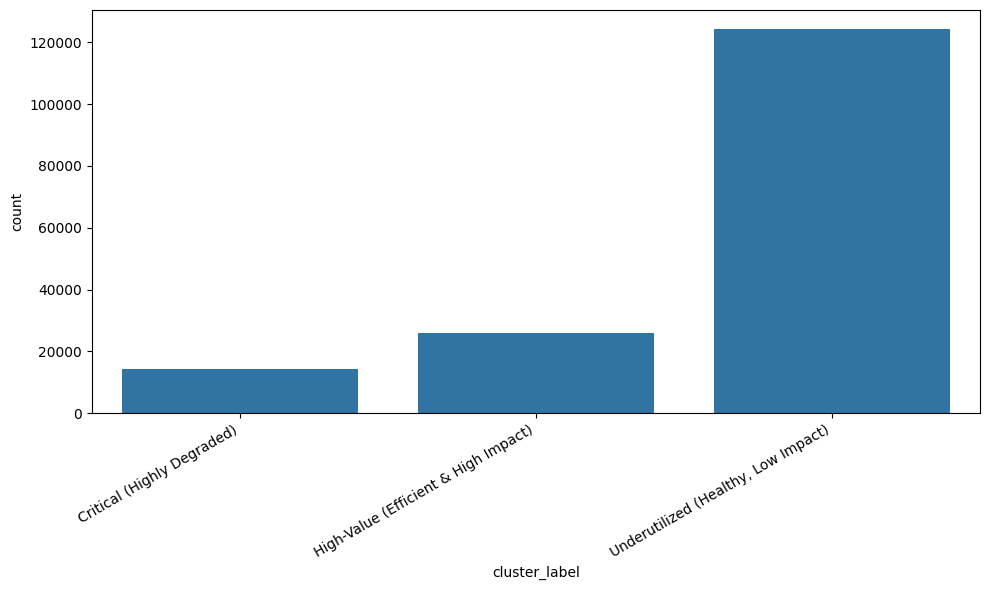

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))  # increase width

sns.countplot(x='cluster_label', data=df)

plt.xticks(rotation=30, ha='right')  # fix overlap
plt.tight_layout()  # prevents cut-off

plt.show()

In [ ]:
district_cluster = df.groupby(['District Name', 'cluster_label']).size().unstack(fill_value=0)
district_cluster

cluster_label,Critical (Highly Degraded),High-Value (Efficient & High Impact),"Underutilized (Healthy, Low Impact)"
District Name,,,
ANANTHAPUR,745,4629,40756
CHITTOOR,2652,961,2851
EAST GODAVARI,838,1705,17810
GUNTUR,432,290,1269
KRISHNA,1832,1611,18247
KURNOOL,116,477,2661
PRAKASAM,761,681,2179
SPS NELLORE,369,728,1359
SRIKAKULAM,1803,5205,1260


In [ ]:
district_cluster_percent = district_cluster.div(district_cluster.sum(axis=1), axis=0) * 100
district_cluster_percent.round(2)

cluster_label,Critical (Highly Degraded),High-Value (Efficient & High Impact),"Underutilized (Healthy, Low Impact)"
District Name,,,
ANANTHAPUR,1.62,10.03,88.35
CHITTOOR,41.03,14.87,44.11
EAST GODAVARI,4.12,8.38,87.51
GUNTUR,21.70,14.57,63.74
KRISHNA,8.45,7.43,84.13
KURNOOL,3.56,14.66,81.78
PRAKASAM,21.02,18.81,60.18
SPS NELLORE,15.02,29.64,55.33
SRIKAKULAM,21.81,62.95,15.24


In [ ]:
district_cluster_percent_sorted = district_cluster_percent.sort_values(
    by='Underutilized (Healthy, Low Impact)',
    ascending=False
)

district_cluster_percent_sorted

cluster_label,Critical (Highly Degraded),High-Value (Efficient & High Impact),"Underutilized (Healthy, Low Impact)"
District Name,,,
WEST GODAVARI,5.236899,5.399512,89.363589
ANANTHAPUR,1.615001,10.034685,88.350314
EAST GODAVARI,4.117329,8.377143,87.505527
KRISHNA,8.446289,7.427386,84.126325
KURNOOL,3.564843,14.658881,81.776275
YSR,8.314011,11.891355,79.794634
GUNTUR,21.697639,14.565545,63.736816
PRAKASAM,21.016294,18.806959,60.176747
SPS NELLORE,15.024430,29.641694,55.333876


DECISION TREE RULES
|--- no_people_benefited_by_water_body <= 12.50
|   |--- efficiency_ratio <= 0.47
|   |   |--- efficiency_ratio <= 0.46
|   |   |   |--- class: Critical (Highly Degraded)
|   |   |--- efficiency_ratio >  0.46
|   |   |   |--- class: Critical (Highly Degraded)
|   |--- efficiency_ratio >  0.47
|   |   |--- no_people_benefited_by_water_body <= 11.50
|   |   |   |--- loss_percentage <= 0.51
|   |   |   |   |--- class: Underutilized (Healthy, Low Impact)
|   |   |   |--- loss_percentage >  0.51
|   |   |   |   |--- class: Underutilized (Healthy, Low Impact)
|   |   |--- no_people_benefited_by_water_body >  11.50
|   |   |   |--- efficiency_ratio <= 0.86
|   |   |   |   |--- class: Underutilized (Healthy, Low Impact)
|   |   |   |--- efficiency_ratio >  0.86
|   |   |   |   |--- class: High-Value (Efficient & High Impact)
|--- no_people_benefited_by_water_body >  12.50
|   |--- loss_percentage <= 0.53
|   |   |--- efficiency_ratio <= 0.50
|   |   |   |--- no_people_benef

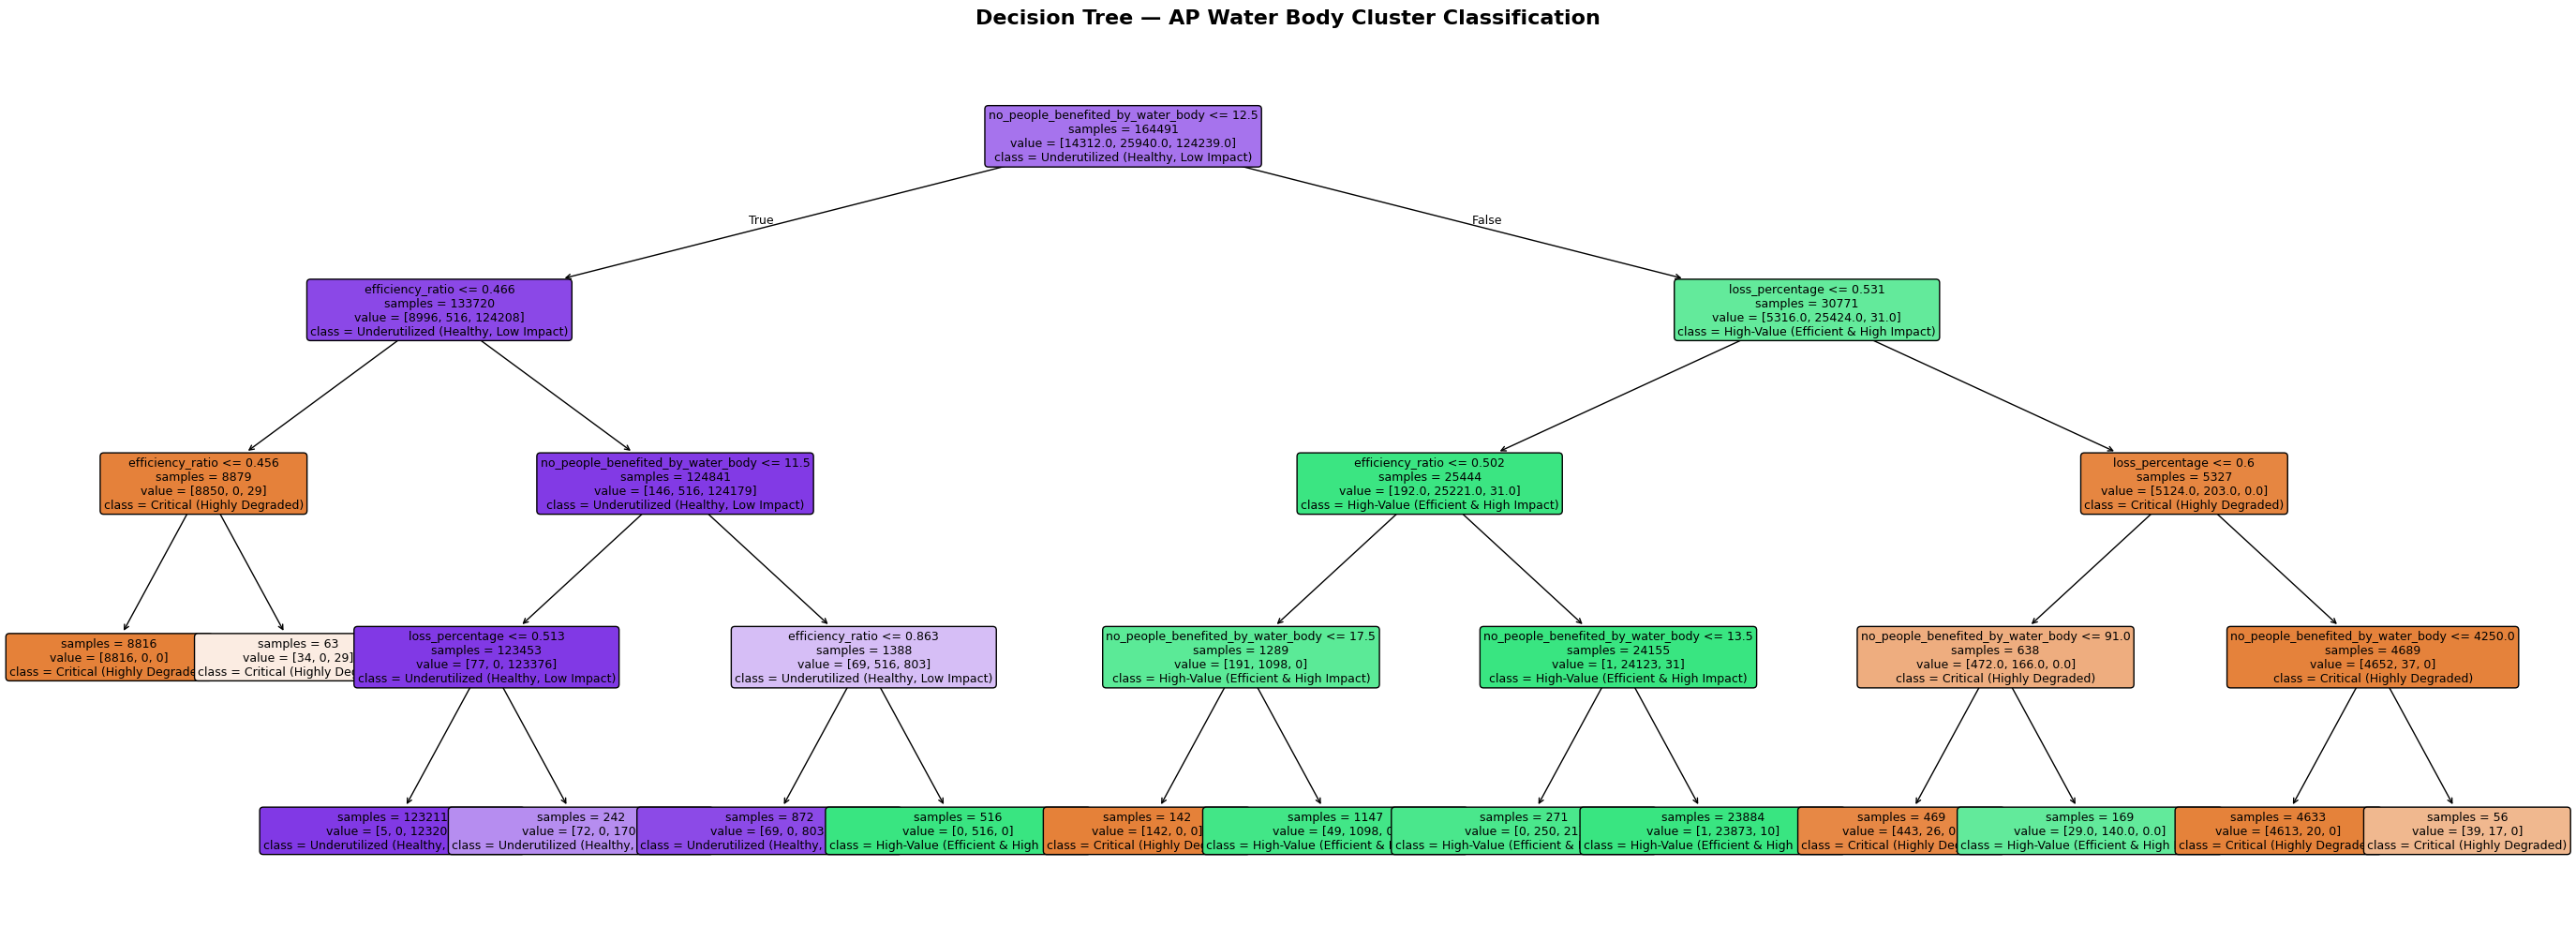

In [ ]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.tree import plot_tree
cat_cols = [
    "rural_or_urban", "water_body_ownership_name",
    "ref_water_body_in_use_id_name", "ref_reason_water_body_in_use_id1_name",
    "ref_selection_id_wua_exists_name", "ref_selection_id_dip_sip_exists_name",
    "ref_selection_id_water_body_encroached_name",
    "ref_water_body_under_repair_renovation_restoration_id_name",
    "filled_up_storage_name", "water_body_nature_name", "ref_water_body_type_id_name",
]
num_cols = [
    "efficiency_ratio", "loss_percentage",
    "storage_capacity_water_body_present", "storage_capacity_water_body_original",
    "water_spread_area_of_water_body", "no_people_benefited_by_water_body",
    "no_villages_benefited", "cca_water_body",
]

cat_cols = [c for c in cat_cols if c in df.columns]
num_cols = [c for c in num_cols if c in df.columns]

# Encode
df_model = df.copy()
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))
for col in num_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

feature_cols = cat_cols + num_cols
X = df_model[feature_cols]
y = df_model["cluster_label"]

# Train
dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, random_state=42)
dt.fit(X, y)

# Print text rules
print("=" * 60)
print("DECISION TREE RULES")
print("=" * 60)
print(export_text(dt, feature_names=feature_cols))



# ── Decision Tree IMAGE ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(28, 10))
plot_tree(
    dt,
    feature_names=feature_cols,
    class_names=dt.classes_,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=False,
    proportion=False,
)
plt.title("Decision Tree — AP Water Body Cluster Classification", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
print("\nAPRIORI RULES PER CLUSTER\n")

for cluster in df["cluster_label"].unique():

    print("\n----------------------------------------")
    print("Cluster:", cluster)
    print("----------------------------------------")

    subset = df[df["cluster_label"] == cluster]

    print("Records:", len(subset))

    data = pd.get_dummies(subset[cat_cols])

    data = data.loc[:, (data.mean() > 0.05) & (data.mean() < 0.95)]

    if data.shape[1] < 2:
        print("Not enough data")
        continue

    freq = apriori(data, min_support=0.1, use_colnames=True)

    if freq.empty:
        print("No frequent items")
        continue


    rules = association_rules(freq, metric="lift", min_threshold=1)

    if rules.empty:
        print("No strong rules")
        continue

    # sort by lift and take top 8
    rules = rules.sort_values(by="lift", ascending=False).head(8)

    print("\nTop Rules (based on lift):\n")

    for _, row in rules.iterrows():
        left = ', '.join(list(row['antecedents']))
        right = ', '.join(list(row['consequents']))

        print("IF", left)
        print("THEN", right)
        print(f"support={row['support']:.3f}, confidence={row['confidence']:.3f}, lift={row['lift']:.3f}")
        print()
        print("-" * 40)
        print()

print("\nDONE")


APRIORI RULES PER CLUSTER


----------------------------------------
Cluster: Critical (Highly Degraded)
----------------------------------------
Records: 14312

Top Rules (based on lift):

IF ref_selection_id_dip_sip_exists_name_No, ref_selection_id_wua_exists_name_Unknown, ref_reason_water_body_in_use_id1_name_Pisciculture
THEN ref_water_body_type_id_name_Tank, water_body_nature_name_Man-made, ref_water_body_in_use_id_name_Yes, water_body_ownership_name_Individual
support=0.110, confidence=0.990, lift=6.593

----------------------------------------

IF ref_selection_id_dip_sip_exists_name_No, water_body_ownership_name_Individual, ref_reason_water_body_in_use_id1_name_Pisciculture
THEN ref_water_body_type_id_name_Tank, water_body_nature_name_Man-made, ref_selection_id_wua_exists_name_Unknown, ref_water_body_in_use_id_name_Yes
support=0.110, confidence=0.990, lift=6.593

----------------------------------------

IF ref_water_body_type_id_name_Tank, water_body_nature_name_Man-made, ref